# NCKH — Pipeline 9 Stage end-to-end

Đây là **notebook tổng hợp duy nhất cho toàn bộ pipeline 9 stage**. Notebook sẽ được xây dựng nối tiếp theo thứ tự Stage 1 → Stage 9; hiện tại phần đã triển khai là **Stage 1 v12.1 — Camera Calibration**.

**Hai input parameters:** `INPUT_VIDEO` và `T0_FRAME_INDEX` (0-based).  
**Đầu ra Stage 1:** `outputs/stage1/camera_state.json`, pitch overlay, evidence overlay, camera 3D QA và gói ZIP.

> Stage 1 chỉ hiệu chỉnh camera/sân. Trạng thái `VALID` không đồng nghĩa với một quyết định việt vị hoàn chỉnh; kết luận cuối chỉ hình thành sau khi các Stage 2–9 được nối vào notebook này.

## 0. Cách chạy notebook tổng

1. Chọn kernel Python 3.9 hoặc 3.10.
2. Nếu máy chưa có dependency, đặt `INSTALL_DEPENDENCIES=True` ở Section 2, chạy cell đó và **Restart Kernel** một lần.
3. Chạy tuần tự từ trên xuống. Các cell tải weight là idempotent: file đúng checksum sẽ không bị tải lại.
4. Chép video vào `inputs/`, sau đó đặt `INPUT_VIDEO` và `T0_FRAME_INDEX` ở Section 5.
5. SoccerNet benchmark và quét toàn video đều tắt mặc định vì tốn thời gian/dung lượng.

### Tiến độ nội dung

- Stage 1 — Camera calibration: **đã triển khai và chạy kiểm thử**.
- Stage 2–9: sẽ bổ sung tiếp vào các phần sau của cùng notebook này.

## 1. Xác định workspace và tạo thư mục runtime

In [1]:
from pathlib import Path
import os, sys, json, shutil, subprocess, hashlib, urllib.request

def find_notebook_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, start / 'notebook_demo']
    for parent in start.parents:
        candidates.extend([parent, parent / 'notebook_demo'])
    for candidate in candidates:
        if (candidate / 'requirements_stage1.txt').is_file() and (candidate / 'pretrained_models').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy folder notebook_demo. Hãy mở notebook từ bên trong D:/NCKH/notebook_demo.')

NOTEBOOK_ROOT = find_notebook_root(Path.cwd())
PROJECT_ROOT = NOTEBOOK_ROOT.parent
STAGE1_ROOT = PROJECT_ROOT / 'stage_1_camera_v12'
DEMO_ROOT = NOTEBOOK_ROOT
INPUTS = NOTEBOOK_ROOT / 'inputs'
OUTPUTS = NOTEBOOK_ROOT / 'outputs' / 'stage1'
WEIGHTS = NOTEBOOK_ROOT / 'pretrained_models' / 'stage1_pnlcalib'
THIRD_PARTY = NOTEBOOK_ROOT / 'third_party'
for path in (INPUTS, OUTPUTS, WEIGHTS, THIRD_PARTY):
    path.mkdir(parents=True, exist_ok=True)

if not (STAGE1_ROOT / 'stage_1_camera').is_dir():
    raise FileNotFoundError(f'Thiếu Stage 1 source: {STAGE1_ROOT}')
if str(STAGE1_ROOT) not in sys.path:
    sys.path.insert(0, str(STAGE1_ROOT))

print('Notebook root :', NOTEBOOK_ROOT)
print('Stage 1 source:', STAGE1_ROOT)
print('Weights       :', WEIGHTS)
print('Outputs       :', OUTPUTS)

Notebook root : D:\NCKH\notebook_demo
Stage 1 source: D:\NCKH\stage_1_camera_v12
Weights       : D:\NCKH\notebook_demo\pretrained_models\stage1_pnlcalib
Outputs       : D:\NCKH\notebook_demo\outputs\stage1


## 2. Cài dependencies

Mặc định cell chỉ kiểm tra, không cài lại môi trường đang dùng. Đặt `INSTALL_DEPENDENCIES=True` khi chạy trên máy/kernel mới.

- `TORCH_WHEEL='cpu'`: chạy được mọi máy, chậm hơn.
- `TORCH_WHEEL='cu121'`: dùng NVIDIA CUDA 12.1 wheel. Chỉ chọn khi driver/GPU tương thích.

Sau khi cài hoặc đổi NumPy/PyTorch, hãy Restart Kernel rồi chạy lại từ đầu.

In [2]:
INSTALL_DEPENDENCIES = False
TORCH_WHEEL = 'cpu'  # đổi thành 'cu121' nếu máy có NVIDIA CUDA phù hợp

if INSTALL_DEPENDENCIES:
    requirements = NOTEBOOK_ROOT / 'requirements_stage1.txt'
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)])
    torch_index = f'https://download.pytorch.org/whl/{TORCH_WHEEL}'
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        'torch==2.3.1', 'torchvision==0.18.1', 'torchaudio==2.3.1',
        '--index-url', torch_index,
    ])
    print('Cài đặt hoàn tất. Hãy Restart Kernel trước khi chạy tiếp.')
else:
    print('Bỏ qua cài đặt. Đặt INSTALL_DEPENDENCIES=True nếu đây là kernel mới.')

Bỏ qua cài đặt. Đặt INSTALL_DEPENDENCIES=True nếu đây là kernel mới.


In [3]:
from importlib.metadata import version as package_version
import numpy as np
import cv2, yaml, scipy, torch, torchvision
import matplotlib.pyplot as plt

import stage_1_camera as stage1_pkg
EXPECTED_STAGE1_VERSION = '0.12.1'
if stage1_pkg.__version__ != EXPECTED_STAGE1_VERSION:
    raise RuntimeError(f'Notebook cần stage_1_camera {EXPECTED_STAGE1_VERSION}, hiện có {stage1_pkg.__version__}')
if np.__version__ != '1.26.4':
    raise RuntimeError(f'Notebook cần NumPy 1.26.4, hiện có {np.__version__}. Chạy lại Section 2 rồi Restart Kernel.')

print('Python      :', sys.version.split()[0])
print('NumPy       :', np.__version__)
print('PyTorch     :', torch.__version__)
print('TorchVision :', torchvision.__version__)
print('OpenCV      :', cv2.__version__)
print('Stage 1     :', stage1_pkg.__version__)
print('CUDA usable :', torch.cuda.is_available())

Python      : 3.9.13
NumPy       : 1.26.4
PyTorch     : 2.3.1+cpu
TorchVision : 0.18.1+cpu
OpenCV      : 4.10.0
Stage 1     : 0.12.1
CUDA usable : False


## 3. Lấy third-party PnLCalib

Cell dưới clone repository chính thức và checkout đúng commit đã được kiểm tra cùng Stage 1 v12: `8c87391d6f4ea40c5e4d65e61529916c7a49ce62`. Nếu máy hiện tại đã có checkout của Stage 1, Git sẽ clone cục bộ để tiết kiệm mạng; trên máy mới nó dùng GitHub.

Nếu `git clone` bị chặn, tải ZIP thủ công từ `https://github.com/mguti97/PnLCalib`, giải nén vào `notebook_demo/third_party/PnLCalib`, rồi checkout/copy đúng source tương ứng commit trên.

In [4]:
PNL_REPOSITORY = 'https://github.com/mguti97/PnLCalib.git'
PNL_COMMIT = '8c87391d6f4ea40c5e4d65e61529916c7a49ce62'
PNL_DIR = THIRD_PARTY / 'PnLCalib'
LOCAL_PNL = STAGE1_ROOT / 'third_party' / 'PnLCalib'

if not (PNL_DIR / '.git').is_dir():
    if PNL_DIR.exists():
        raise RuntimeError(f'{PNL_DIR} tồn tại nhưng không phải Git checkout; hãy đổi tên/xóa thủ công sau khi kiểm tra.')
    clone_source = str(LOCAL_PNL) if (LOCAL_PNL / '.git').is_dir() else PNL_REPOSITORY
    print('Cloning PnLCalib from:', clone_source)
    subprocess.check_call(['git', 'clone', clone_source, str(PNL_DIR)])

current_commit = subprocess.check_output(['git', '-C', str(PNL_DIR), 'rev-parse', 'HEAD'], text=True).strip()
if current_commit != PNL_COMMIT:
    dirty = subprocess.run(['git', '-C', str(PNL_DIR), 'diff', '--quiet']).returncode != 0
    if dirty:
        raise RuntimeError('PnLCalib checkout có thay đổi chưa commit; notebook không tự ghi đè.')
    subprocess.check_call(['git', '-C', str(PNL_DIR), 'fetch', 'origin', PNL_COMMIT])
    subprocess.check_call(['git', '-C', str(PNL_DIR), 'checkout', '--detach', PNL_COMMIT])

assert (PNL_DIR / 'inference.py').is_file()
print('PnLCalib:', PNL_DIR)
print('Commit   :', subprocess.check_output(['git', '-C', str(PNL_DIR), 'rev-parse', 'HEAD'], text=True).strip())

PnLCalib: D:\NCKH\notebook_demo\third_party\PnLCalib
Commit   : 8c87391d6f4ea40c5e4d65e61529916c7a49ce62


## 4. Tải pretrained weights và kiểm tra SHA-256

Notebook dùng `SV_kp` + `SV_lines` cho demo một ảnh/video. `MV_kp` + `MV_lines` dành cho benchmark SoccerNet.

Nếu cell tải tự động không chạy được, tải thủ công bằng trình duyệt rồi đặt đúng tên vào `notebook_demo/pretrained_models/stage1_pnlcalib/`:

- https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/SV_kp
- https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/SV_lines
- https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/MV_kp
- https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/MV_lines

Không đổi tên và không dùng một file cho cả keypoint lẫn line model.

In [5]:
WEIGHT_SPECS = {
    'SV_kp': {
        'url': 'https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/SV_kp',
        'sha256': '7ea78fa76aaf94976a8eca428d6e3c59697a93430cba1a4603e20284b61f5113',
    },
    'SV_lines': {
        'url': 'https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/SV_lines',
        'sha256': 'd72f4ed71734a2e3df9fa084f666e9b8adaef21bf69bac8952d6d3f970ff7455',
    },
    'MV_kp': {
        'url': 'https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/MV_kp',
        'sha256': 'd6cc28f8c342b9aae46b9adbeec196cdf10f6bd8759771aa61c55c620c20bf20',
    },
    'MV_lines': {
        'url': 'https://github.com/mguti97/PnLCalib/releases/download/v1.0.0/MV_lines',
        'sha256': '462ac7b3692d368dac1341a5af90143c1b8ce9e97d257b3787039b8cbc5af274',
    },
}

def sha256_file(path: Path, chunk_size: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

def download_file(url: str, destination: Path) -> None:
    temporary = destination.with_name(destination.name + '.part')
    request = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 Stage1Notebook/1.0'})
    with urllib.request.urlopen(request) as response, temporary.open('wb') as output:
        shutil.copyfileobj(response, output, length=8 * 1024 * 1024)
    temporary.replace(destination)

for name, spec in WEIGHT_SPECS.items():
    destination = WEIGHTS / name
    current_hash = sha256_file(destination) if destination.is_file() else None
    if current_hash != spec['sha256']:
        if destination.exists():
            destination.rename(destination.with_name(destination.name + '.invalid'))
        print('Downloading:', name)
        download_file(spec['url'], destination)
        current_hash = sha256_file(destination)
    if current_hash != spec['sha256']:
        raise RuntimeError(f'Checksum sai cho {name}: {current_hash}')
    print(f'{name:8s} OK  {destination.stat().st_size / 1024**2:.1f} MiB')

SV_kp    OK  252.7 MiB
SV_lines OK  252.6 MiB
MV_kp    OK  252.7 MiB
MV_lines OK  252.6 MiB


## 5. Khai báo video và frame `t0`

Đây là cell cấu hình đầu vào chính của notebook. `T0_FRAME_INDEX` dùng quy ước **0-based**: frame đầu tiên là 0. Notebook kiểm tra range, seek đúng frame và hiển thị lại để xác nhận trước khi inference. Frame `t0` nên có đủ nhiều vạch sân rõ.

Input video : D:\NCKH\notebook_demo\inputs\input.mp4
Total frames: 213
FPS         : 30.0
t0 frame    : 104 (0-based)
t0 time [s] : 3.466666666666667
Frame size  : 1920 x 1080


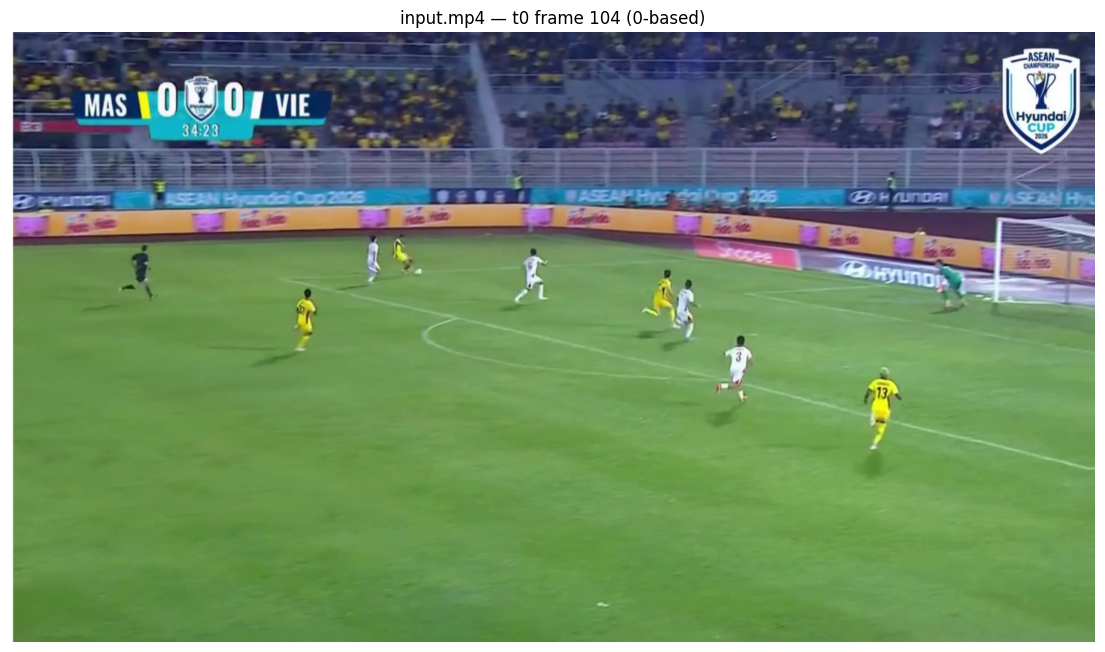

In [6]:
# ===== INPUT PARAMETERS — chỉnh đúng hai dòng này =====
INPUT_VIDEO = INPUTS / 'input.mp4'
T0_FRAME_INDEX = 104  # 0-based: frame đầu tiên của video là 0
# ====================================================

if not INPUT_VIDEO.is_file():
    raise FileNotFoundError(f'Không tìm thấy video: {INPUT_VIDEO}')
if not isinstance(T0_FRAME_INDEX, int) or T0_FRAME_INDEX < 0:
    raise ValueError('T0_FRAME_INDEX phải là số nguyên >= 0 theo quy ước 0-based.')

capture = cv2.VideoCapture(str(INPUT_VIDEO))
if not capture.isOpened():
    raise RuntimeError(f'OpenCV không mở được video: {INPUT_VIDEO}')
total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
video_fps = float(capture.get(cv2.CAP_PROP_FPS) or 0.0)
if total_frames > 0 and T0_FRAME_INDEX >= total_frames:
    capture.release()
    raise IndexError(f't0={T0_FRAME_INDEX} ngoài video có {total_frames} frame (range: 0..{total_frames-1}).')
capture.set(cv2.CAP_PROP_POS_FRAMES, T0_FRAME_INDEX)
ok, frame = capture.read()
actual_frame_index = int(capture.get(cv2.CAP_PROP_POS_FRAMES)) - 1
capture.release()
if not ok or frame is None:
    raise RuntimeError(f'Không đọc được frame t0={T0_FRAME_INDEX} từ {INPUT_VIDEO}')
if actual_frame_index != T0_FRAME_INDEX:
    raise RuntimeError(f'Video backend trả frame {actual_frame_index}, khác t0 yêu cầu {T0_FRAME_INDEX}.')

FRAME_INDEX = T0_FRAME_INDEX
height, width = frame.shape[:2]
t0_seconds = (T0_FRAME_INDEX / video_fps) if video_fps > 0 else None
print('Input video :', INPUT_VIDEO)
print('Total frames:', total_frames)
print('FPS         :', video_fps)
print('t0 frame    :', T0_FRAME_INDEX, '(0-based)')
print('t0 time [s] :', t0_seconds)
print('Frame size  :', width, 'x', height)
plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f'{INPUT_VIDEO.name} — t0 frame {T0_FRAME_INDEX} (0-based)')
plt.axis('off')
plt.show()

## 6. Nạp hai mạng PnLCalib

Ngưỡng single-view giữ đúng demo Stage 1 hiện tại: keypoint `0.3434`, line `0.7867`. `PNL_REFINE=True` bật refinement bằng line evidence.

In [7]:
import torchvision.transforms as T

if str(PNL_DIR) not in sys.path:
    sys.path.insert(0, str(PNL_DIR))

import inference as pnl_inf
from model.cls_hrnet import get_cls_net
from model.cls_hrnet_l import get_cls_net as get_cls_net_l
from utils.utils_calib import (
    FramebyFrameCalib, keypoint_world_coords_2D, keypoint_aux_world_coords_2D,
)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
KP_THRESHOLD = 0.3434
LINE_THRESHOLD = 0.7867
PNL_REFINE = True
RUN_CANDIDATE_DIAGNOSTICS = True

pnl_inf.device = str(DEVICE)
pnl_inf.transform2 = T.Resize((540, 960))
cfg_kp = yaml.safe_load((PNL_DIR / 'config' / 'hrnetv2_w48.yaml').read_text(encoding='utf-8'))
cfg_line = yaml.safe_load((PNL_DIR / 'config' / 'hrnetv2_w48_l.yaml').read_text(encoding='utf-8'))

model_kp = get_cls_net(cfg_kp)
model_line = get_cls_net_l(cfg_line)
model_kp.load_state_dict(torch.load(WEIGHTS / 'SV_kp', map_location=DEVICE))
model_line.load_state_dict(torch.load(WEIGHTS / 'SV_lines', map_location=DEVICE))
model_kp.to(DEVICE).eval()
model_line.to(DEVICE).eval()
print('Models ready on:', DEVICE)

Models ready on: cpu


## 7. Hàm suy luận Stage 1

Ngoài camera cuối, hàm lưu evidence pixel↔world và candidate diagnostics. Đây là dữ liệu cần để frozen capability policies phân biệt ground geometry với vertical 3D readiness.

In [8]:
from stage_1_camera.evidence import summarize_keypoint_coverage, build_keypoint_correspondences
from stage_1_camera.pnlcalib_adapter import PnLCalibAdapter
from stage_1_camera.candidates import collect_pnlcalib_candidates, clone_calibration_for_candidate_diagnostics
from stage_1_camera.pipeline import build_camera_state_from_pnlcalib

def world_lookups_for_keypoints(keypoints_used):
    world_xy_lookup, world_xyz_lookup = {}, {}
    elevated_main_ids = {12, 15, 16, 19}
    transform_pnl_to_canonical = PnLCalibAdapter.PNL_TO_CANONICAL
    n_main = len(keypoint_world_coords_2D)
    for raw_id in keypoints_used.keys():
        try:
            keypoint_id = int(raw_id)
        except (TypeError, ValueError):
            continue
        if 1 <= keypoint_id <= n_main:
            xy = keypoint_world_coords_2D[keypoint_id - 1]
            z_pnl = -2.44 if keypoint_id in elevated_main_ids else 0.0
        else:
            aux_index = keypoint_id - 1 - n_main
            if not (0 <= aux_index < len(keypoint_aux_world_coords_2D)):
                continue
            xy = keypoint_aux_world_coords_2D[aux_index]
            z_pnl = 0.0
        xyz_pnl = np.array([float(xy[0]), float(xy[1]), float(z_pnl)], dtype=np.float64)
        xyz_canonical = transform_pnl_to_canonical @ xyz_pnl
        world_xy_lookup[keypoint_id] = xyz_canonical[:2].tolist()
        world_xyz_lookup[keypoint_id] = xyz_canonical.tolist()
    return world_xy_lookup, world_xyz_lookup

def run_pnl_inference(frame_bgr, frame_index=0, run_candidates=True):
    image_height, image_width = frame_bgr.shape[:2]
    calibration = FramebyFrameCalib(iwidth=image_width, iheight=image_height, denormalize=True)
    result = pnl_inf.inference(
        calibration, frame_bgr, model_kp, model_line,
        kp_threshold=KP_THRESHOLD, line_threshold=LINE_THRESHOLD, pnl_refine=PNL_REFINE,
    )
    if result is None:
        return None, calibration

    keypoints_used = getattr(calibration, 'keypoints_dict', {}) or {}
    lines_used = getattr(calibration, 'lines_dict', {}) or {}
    world_xy, world_xyz = world_lookups_for_keypoints(keypoints_used)
    coverage = summarize_keypoint_coverage(
        keypoints_used, image_width=image_width, image_height=image_height, world_xy_lookup=world_xy,
    )
    result['pnl_refine'] = PNL_REFINE
    result['evidence'] = {
        'num_keypoints_used': len(keypoints_used),
        'num_lines_used': len(lines_used),
        'kp_threshold': KP_THRESHOLD,
        'line_threshold': LINE_THRESHOLD,
        'keypoint_correspondences': build_keypoint_correspondences(keypoints_used, world_xyz),
        **{f'keypoint_{key}': value for key, value in coverage.items()},
    }
    if run_candidates:
        diagnostic_calibration = clone_calibration_for_candidate_diagnostics(calibration, FramebyFrameCalib)
        result['candidate_diagnostics'] = collect_pnlcalib_candidates(
            diagnostic_calibration, refine=False, refine_lines=PNL_REFINE, selected_result=result,
        )
    return result, calibration

## 8. Chạy inference, chuẩn hóa camera và áp frozen gate

In [9]:
pnl_result, calibration = run_pnl_inference(
    frame, frame_index=FRAME_INDEX, run_candidates=RUN_CANDIDATE_DIAGNOSTICS,
)
if pnl_result is None:
    raise RuntimeError('PnLCalib không tìm được nghiệm camera. Hãy thử frame có nhiều vạch sân rõ hơn.')

camera_state = build_camera_state_from_pnlcalib(
    pnl_result,
    frame_index=FRAME_INDEX,
    image_width=width,
    image_height=height,
    pnl_refine=PNL_REFINE,
    source_extra={
        'backend': 'PnLCalib',
        'pnl_commit': PNL_COMMIT,
        'weights_kp': 'SV_kp',
        'weights_lines': 'SV_lines',
        'kp_threshold': KP_THRESHOLD,
        'line_threshold': LINE_THRESHOLD,
    },
)

camera_json = OUTPUTS / 'camera_state.json'
camera_state.save_json(str(camera_json))
print('Saved:', camera_json)

Saved: D:\NCKH\notebook_demo\outputs\stage1\camera_state.json


## 9. Kết quả định lượng và candidate audit

In [10]:
capabilities = camera_state.diagnostics.get('capabilities', {}) or {}
quality_gate = camera_state.diagnostics.get('quality_gate', {}) or {}
candidate_diagnostics = camera_state.diagnostics.get('candidate_diagnostics', {}) or {}
summary = {
    'frame_index': camera_state.frame_index,
    'camera_status': camera_state.status.value,
    'ground_geometry': (capabilities.get('ground_geometry') or {}).get('status'),
    'vertical_3d': (capabilities.get('vertical_3d') or {}).get('status'),
    'offside_3d_ready': capabilities.get('offside_3d_ready'),
    'selected_mode': pnl_result.get('mode'),
    'selected_ransac': pnl_result.get('use_ransac'),
    'reprojection_error_px': pnl_result.get('rep_err'),
    'num_keypoints': camera_state.evidence.get('num_keypoints_used'),
    'num_lines': camera_state.evidence.get('num_lines_used'),
    'camera_center_world_m': camera_state.camera_center_world_m.tolist(),
    'fx_px': float(camera_state.K[0, 0]),
    'warnings': quality_gate.get('warnings', []),
}
(OUTPUTS / 'summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(summary, indent=2, ensure_ascii=False))

rows = candidate_diagnostics.get('candidates', [])
if rows:
    print(f"\n{'SEL':<4} {'mode':<13} {'RANSAC':>6} {'success':>8} {'rep_err_px':>11}")
    print('-' * 50)
    for row in rows:
        rep = row.get('rep_err_px')
        rep_text = '-' if rep is None else f'{rep:.3f}'
        print(f"{('*' if row.get('selected') else ''):<4} {row.get('mode','-'):<13} {row.get('use_ransac','-'):>6} {str(row.get('success')):>8} {rep_text:>11}")

{
  "frame_index": 104,
  "camera_status": "VALID",
  "ground_geometry": "VALID",
  "vertical_3d": "DEGRADED",
  "offside_3d_ready": false,
  "selected_mode": "main",
  "selected_ransac": 0,
  "reprojection_error_px": 0.27469477903499423,
  "num_keypoints": 12,
  "num_lines": 0,
  "camera_center_world_m": [
    77.55106351104135,
    40.82785718300569,
    4.653416270324924
  ],
  "fx_px": 2398.1513517970357,
  "warnings": []
}

SEL  mode          RANSAC  success  rep_err_px
--------------------------------------------------
     full               0     True       7.886
     full               5     True       3.235
     full              10     True       3.235
     full              15     True       8.318
     full              25     True       7.886
     full              50     True       7.886
     ground_plane       0     True       7.886
     ground_plane       5     True       3.235
     ground_plane      10     True       3.235
     ground_plane      15     True       8.318

## 10. Visual QA: pitch registration, evidence và camera 3D

Pitch overlay phải bám các vạch sân thật. Evidence overlay cho biết keypoints/line extremities mà model đã dùng. Hình 3D giúp phát hiện camera centre hoặc optical axis phi vật lý.

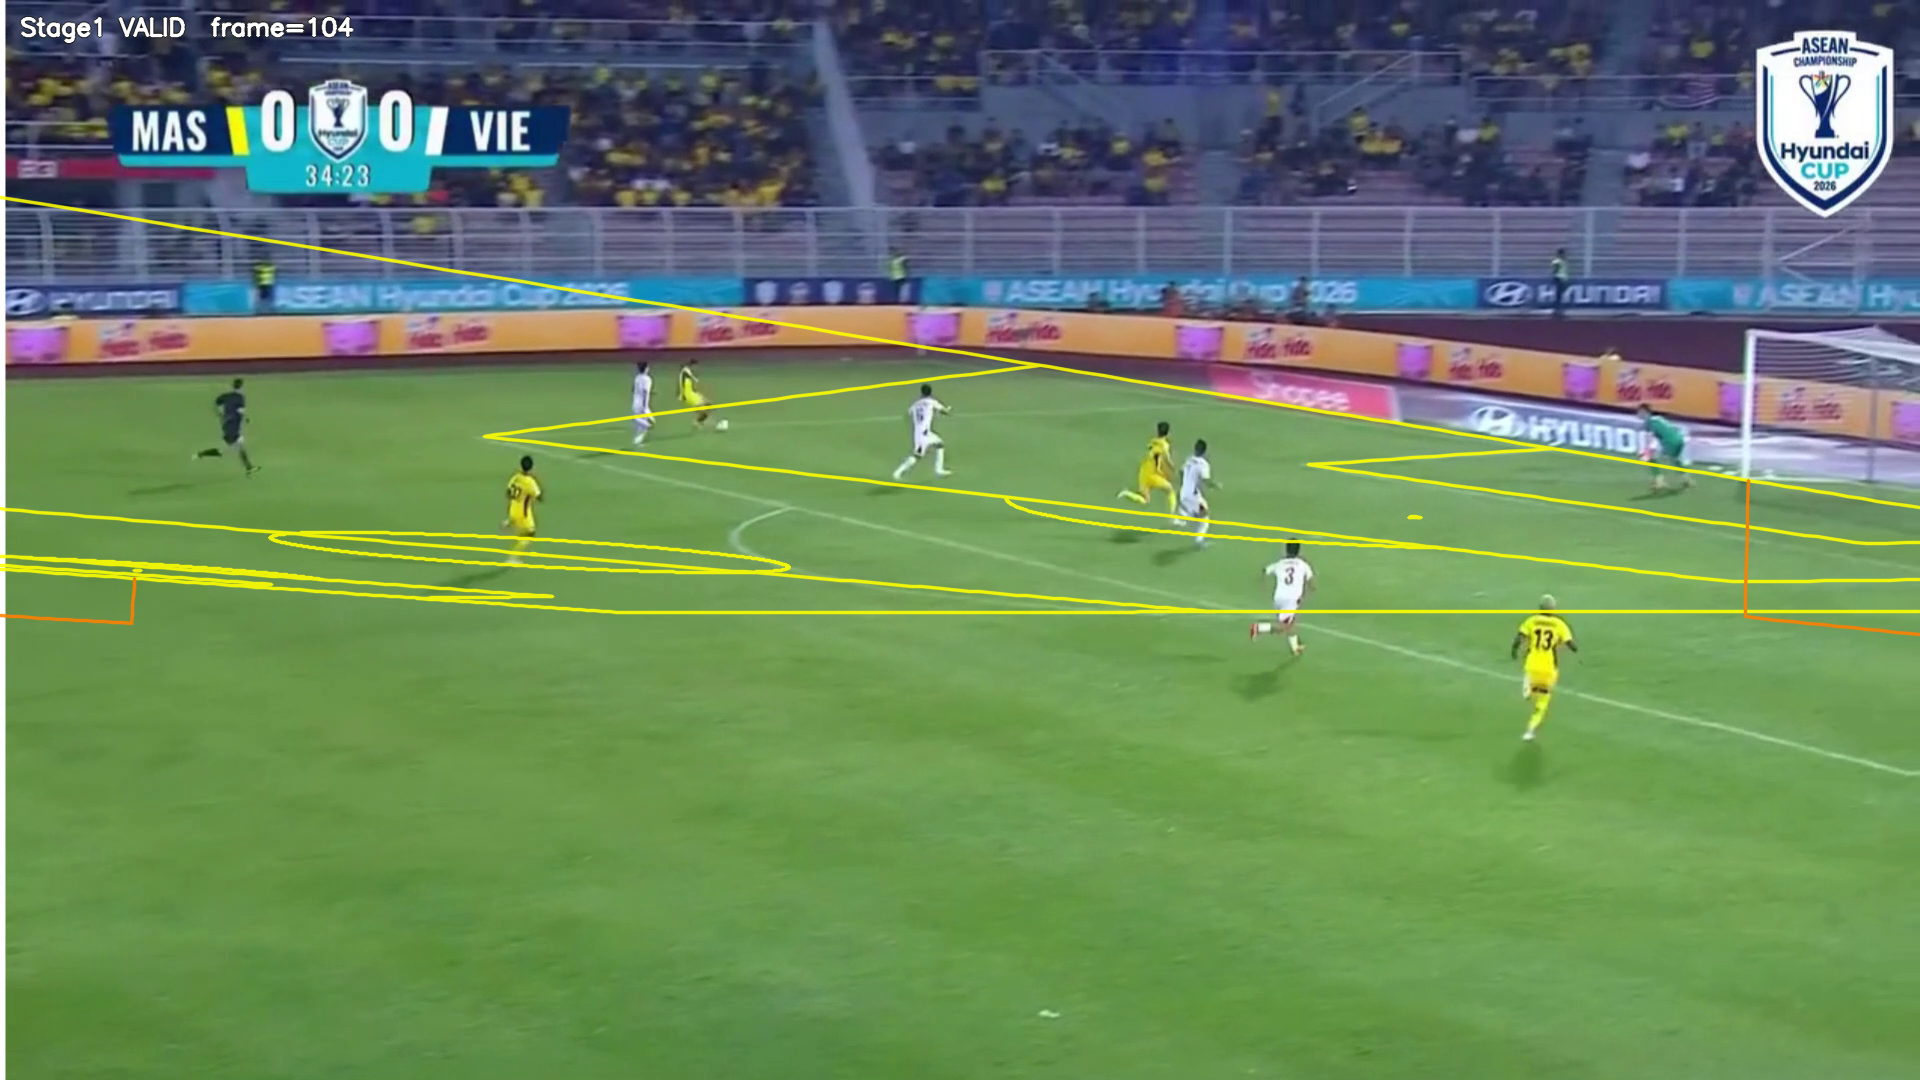

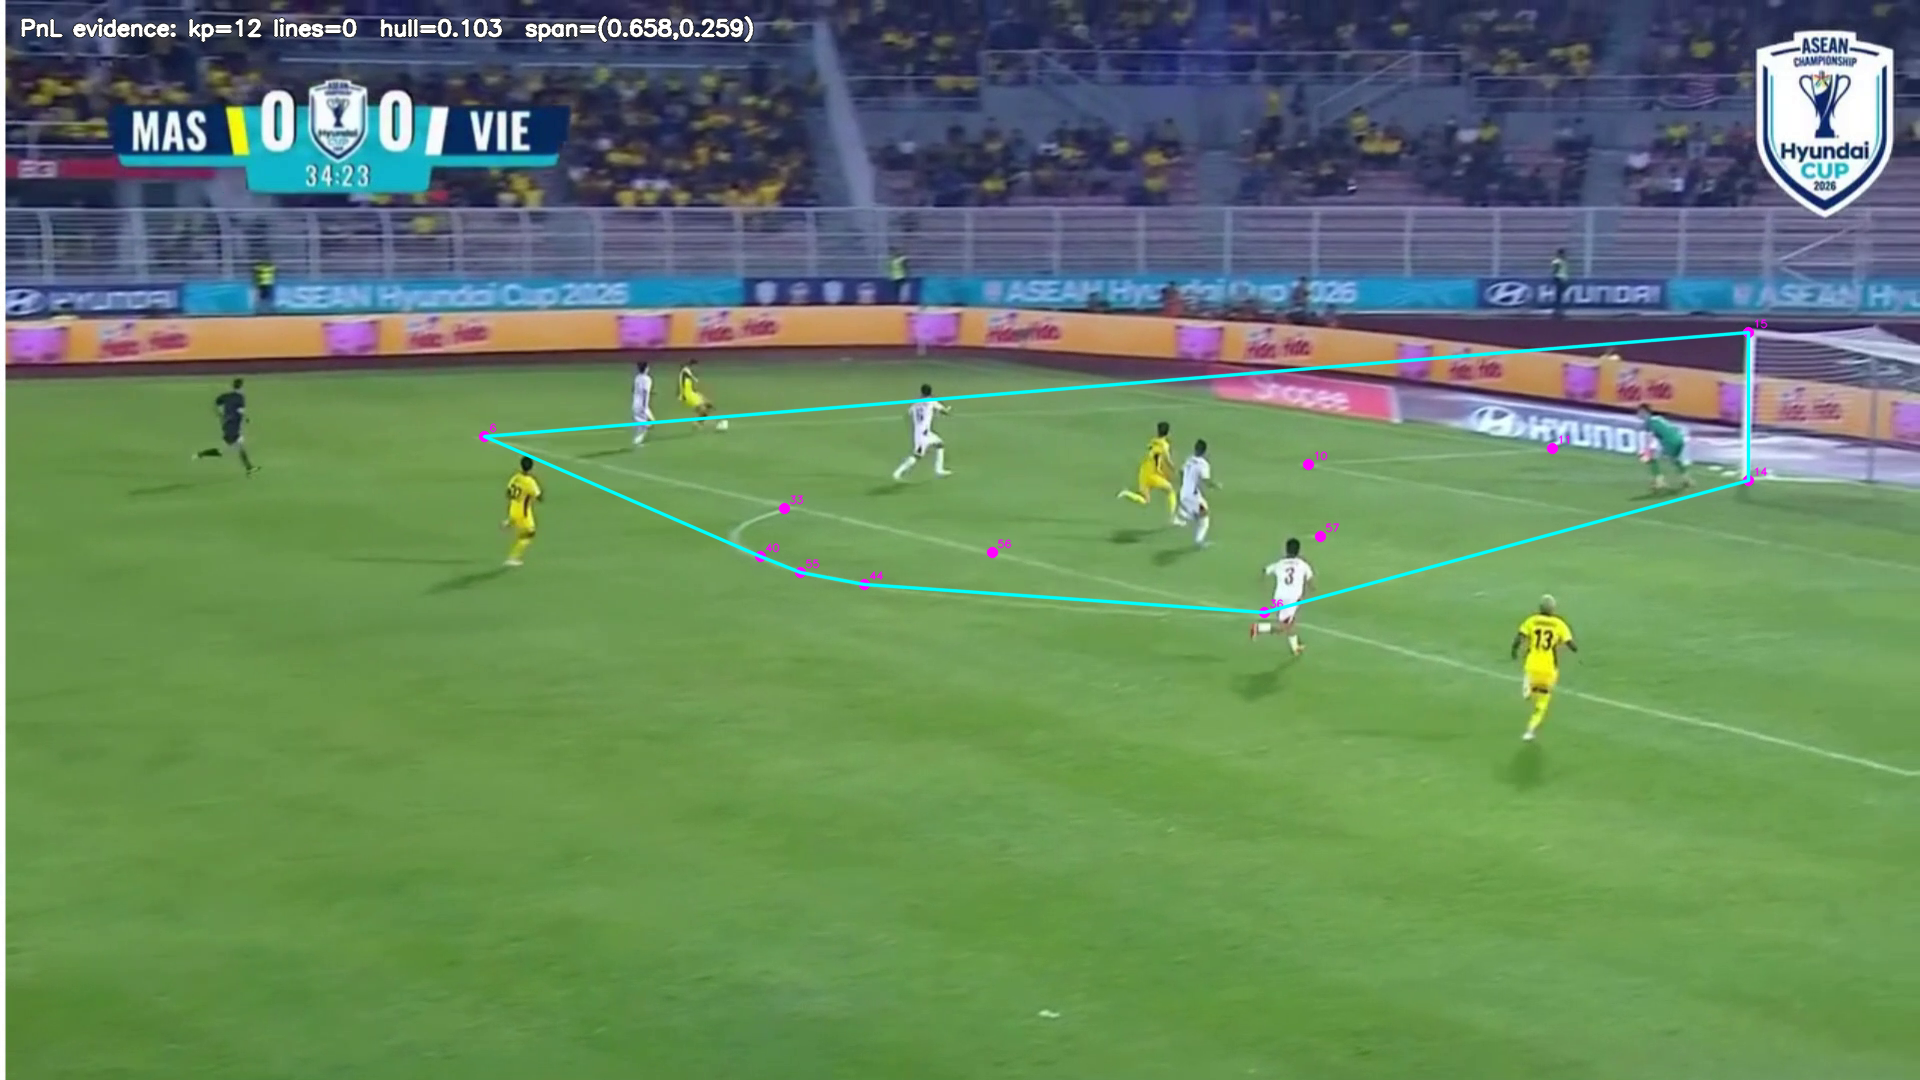

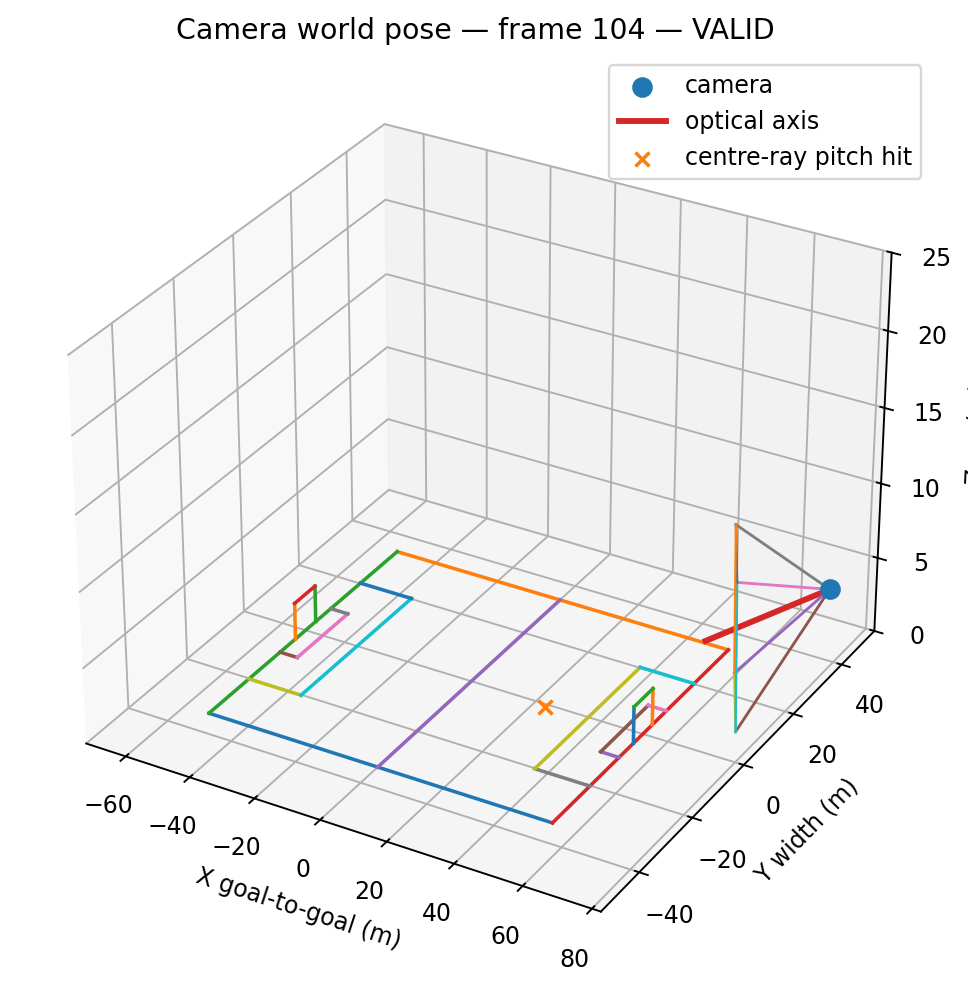

In [11]:
from IPython.display import display, Image as IPyImage
from stage_1_camera.visualization import render_pitch_overlay, render_evidence_overlay, save_camera_3d_view

pitch_overlay_path = OUTPUTS / 'pitch_registration_overlay.png'
evidence_overlay_path = OUTPUTS / 'pnl_evidence_overlay.png'
camera_3d_path = OUTPUTS / 'camera_3d_qa.png'

pitch_overlay = render_pitch_overlay(frame, camera_state, thickness=2, alpha=0.88)
evidence_overlay = render_evidence_overlay(
    frame,
    keypoints=getattr(calibration, 'keypoints_dict', None),
    lines=getattr(calibration, 'lines_dict', None),
    draw_keypoint_hull=True,
    coverage_metrics=camera_state.evidence,
)
if not cv2.imwrite(str(pitch_overlay_path), pitch_overlay):
    raise IOError(f'Không ghi được {pitch_overlay_path}')
if not cv2.imwrite(str(evidence_overlay_path), evidence_overlay):
    raise IOError(f'Không ghi được {evidence_overlay_path}')
save_camera_3d_view(camera_state, str(camera_3d_path), frustum_length_m=25.0, optical_axis_length_m=30.0)

display(IPyImage(filename=str(pitch_overlay_path)))
display(IPyImage(filename=str(evidence_overlay_path)))
display(IPyImage(filename=str(camera_3d_path)))

## 11. Geometry smoke test và đóng gói artifact

In [12]:
world_points = np.array([[0.0, 0.0, 0.0], [10.0, 5.0, 0.0], [-20.0, -10.0, 0.0]])
pixels = camera_state.project_world(world_points)
reconstructed = camera_state.intersect_pitch(pixels)
roundtrip_error_m = float(np.nanmax(np.linalg.norm(reconstructed - world_points, axis=1)))
print('Max world→pixel→pitch round-trip error [m]:', roundtrip_error_m)
if roundtrip_error_m > 1e-5:
    raise RuntimeError('Geometry round-trip vượt tolerance; không nên bàn giao artifact này.')

archive_base = NOTEBOOK_ROOT / 'outputs' / 'stage1_camera_artifacts'
archive_path = Path(shutil.make_archive(str(archive_base), 'zip', root_dir=OUTPUTS))
print('Artifact package:', archive_path)

Max world→pixel→pitch round-trip error [m]: 2.523177173623694e-13
Artifact package: D:\NCKH\notebook_demo\outputs\stage1_camera_artifacts.zip


## 12. Quét video tùy chọn

Cell này dùng lại `INPUT_VIDEO` đã khai báo ở Section 5, chạy calibration độc lập trên mỗi `VIDEO_STRIDE` frame và tạo overlay video. Đây là demo per-frame, **không phải** temporal rescue/PTZ optimizer của notebook nghiên cứu dài. Frame `t0` vẫn là artifact chính ở Sections 8–11.

In [13]:
RUN_VIDEO_DEMO = False
VIDEO_STRIDE = 5

if RUN_VIDEO_DEMO:
    from stage_1_camera.visualization import render_pitch_overlay
    capture = cv2.VideoCapture(str(INPUT_VIDEO))
    if not capture.isOpened():
        raise FileNotFoundError(f'Không mở được video: {INPUT_VIDEO}')
    video_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    source_fps = capture.get(cv2.CAP_PROP_FPS) or 25.0
    output_video = OUTPUTS / 'stage1_pitch_overlay.mp4'
    writer = cv2.VideoWriter(
        str(output_video), cv2.VideoWriter_fourcc(*'mp4v'),
        source_fps / VIDEO_STRIDE, (video_width, video_height),
    )
    states_dir = OUTPUTS / 'video_camera_states'
    states_dir.mkdir(parents=True, exist_ok=True)
    frame_index, solved = 0, 0
    while True:
        ok, video_frame = capture.read()
        if not ok:
            break
        if frame_index % VIDEO_STRIDE == 0:
            result, _ = run_pnl_inference(video_frame, frame_index=frame_index, run_candidates=False)
            if result is not None:
                state = build_camera_state_from_pnlcalib(
                    result, frame_index=frame_index, image_width=video_width, image_height=video_height,
                    pnl_refine=PNL_REFINE,
                    source_extra={'backend': 'PnLCalib', 'weights_kp': 'SV_kp', 'weights_lines': 'SV_lines'},
                )
                state.save_json(str(states_dir / f'camera_state_{frame_index:08d}.json'))
                rendered = render_pitch_overlay(video_frame, state, thickness=2, alpha=0.88)
                solved += 1
            else:
                rendered = video_frame.copy()
                cv2.putText(rendered, 'NO CAMERA SOLUTION', (24, 48), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)
            writer.write(rendered)
        frame_index += 1
    capture.release()
    writer.release()
    print(f'Saved {output_video}; solved {solved} sampled frames.')
else:
    print('Video demo đang tắt.')

Video demo đang tắt.


## 13. SoccerNet Calibration-2023 benchmark tùy chọn

Dataset lớn và có thể phụ thuộc quyền truy cập của SoccerNet/Hugging Face, nên notebook không tự tải khi Run All. Đặt `DOWNLOAD_SOCCERNET=True` để thử downloader chính thức. Nếu bị yêu cầu đăng nhập/quyền truy cập, tải thủ công theo hướng dẫn tại https://www.soccer-net.org/data rồi đặt cấu trúc `train/`, `valid/`, `test/` dưới `SOCCERNET_ROOT`. Không ghi token hoặc mật khẩu trực tiếp vào notebook.

Smoke benchmark dùng `MV_kp` + `MV_lines` và ngưỡng frozen của runner v12.

In [14]:
DOWNLOAD_SOCCERNET = False
SOCCERNET_BASE = NOTEBOOK_ROOT / 'datasets' / 'SoccerNet'
SOCCERNET_ROOT = SOCCERNET_BASE / 'calibration-2023'

if DOWNLOAD_SOCCERNET:
    from SoccerNet.Downloader import SoccerNetDownloader
    downloader = SoccerNetDownloader(LocalDirectory=str(SOCCERNET_BASE))
    downloader.downloadDataTask(
        task='calibration-2023', split=['train', 'valid', 'test'], source='HuggingFace',
    )
else:
    print('Dataset download đang tắt. Expected root:', SOCCERNET_ROOT)

Dataset download đang tắt. Expected root: D:\NCKH\notebook_demo\datasets\SoccerNet\calibration-2023


In [15]:
RUN_SOCCERNET_SMOKE = False
SOCCERNET_SMOKE_LIMIT = 100 if torch.cuda.is_available() else 20

if RUN_SOCCERNET_SMOKE:
    from stage_1_camera.evaluation.soccernet_benchmark import (
        inspect_dataset, SoccerNetBenchmarkConfig, SoccerNetCalibrationBenchmark,
    )
    integrity = inspect_dataset(SOCCERNET_ROOT, splits=('valid',), auto_extract=True)
    print(json.dumps(integrity, indent=2))
    if not integrity['splits']['valid']['ready']:
        raise RuntimeError('SoccerNet valid split chưa sẵn sàng.')
    benchmark = SoccerNetCalibrationBenchmark(
        pnl_dir=PNL_DIR,
        weights_kp=WEIGHTS / 'MV_kp',
        weights_line=WEIGHTS / 'MV_lines',
        device=str(DEVICE),
        config=SoccerNetBenchmarkConfig(split='valid', limit=SOCCERNET_SMOKE_LIMIT),
    )
    benchmark_result = benchmark.run(
        SOCCERNET_ROOT, OUTPUTS / 'soccernet_valid_smoke', prefix='valid_smoke',
    )
    print(json.dumps(benchmark_result['summary'], indent=2, ensure_ascii=False))
else:
    print('SoccerNet smoke benchmark đang tắt.')

SoccerNet smoke benchmark đang tắt.


## 14. Definition of Done

Stage 1 demo hoàn tất khi:

- `camera_state.json` được sinh từ inference thật, không dùng mock fallback;
- pitch overlay bám vạch sân khi kiểm tra bằng mắt;
- evidence overlay có phân bố keypoint hợp lý;
- geometry round-trip pass;
- đọc riêng `ground_geometry`, `vertical_3d` và `offside_3d_ready` thay vì suy diễn từ một status duy nhất;
- giữ toàn bộ artifact trong `outputs/` hoặc gói `stage1_camera_artifacts.zip` để bàn giao sang stage tiếp theo.